In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *
from modules.index.visualisation import plot_indices_with_returns

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (104, 127)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find EI variants
ei_variants = ['ei_community', 'ei_community_topicweighted', 'ei_creator', 'ei_creator_engweighted', 'ei_creator_topicweighted']
ASSET_COLS = ['r_btc', 'r_gold', 'r_spx']
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nEI variants found: {len(ei_variants)}")
for i, var in enumerate(ei_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


EI variants found: 5
  1. ei_community
  2. ei_community_topicweighted
  3. ei_creator
  4. ei_creator_engweighted
  5. ei_creator_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx']


## Test Framework Functions


TEST 1: Descriptive Statistics

EI Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
ei_community,104.0,-0.321000,0.113168,-0.511403,-0.380581,-0.335871,-0.289797,0.217822,2.130533,6.988254,0.0,0.000000
ei_community_topicweighted,104.0,-0.306903,0.108233,-0.487246,-0.363673,-0.324107,-0.276945,0.209872,2.138986,7.030251,0.0,0.000000
ei_creator,104.0,-0.131572,0.258837,-1.000000,-0.250000,-0.157922,0.000000,0.666667,-0.015776,2.454899,0.0,12.500000
ei_creator_engweighted,104.0,-0.156446,0.262870,-1.000000,-0.279100,-0.183008,0.000000,0.653797,0.095213,2.037811,0.0,7.692308
ei_creator_topicweighted,104.0,-0.090404,0.187417,-0.528942,-0.228683,-0.098845,0.001093,0.495902,0.482402,0.337184,0.0,6.730769



Correlation between variants:


,ei_community,ei_community_topicweighted,ei_creator,ei_creator_engweighted,ei_creator_topicweighted
ei_community,1.000000,0.999465,0.052050,0.071724,0.108875
ei_community_topicweighted,0.999465,1.000000,0.052643,0.072726,0.112471
ei_creator,0.052050,0.052643,1.000000,0.985142,0.728408
ei_creator_engweighted,0.071724,0.072726,0.985142,1.000000,0.708265
ei_creator_topicweighted,0.108875,0.112471,0.728408,0.708265,1.000000


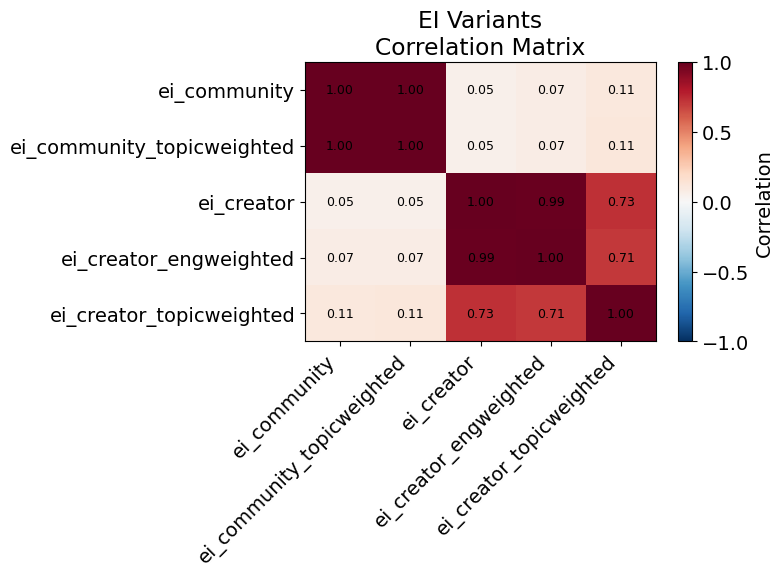

In [5]:
# Test: Descriptive statistics
print("\n" + "="*70)
print("TEST 1: Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, ei_variants, 'EI Variants')


TEST 2: Time Series Visualization


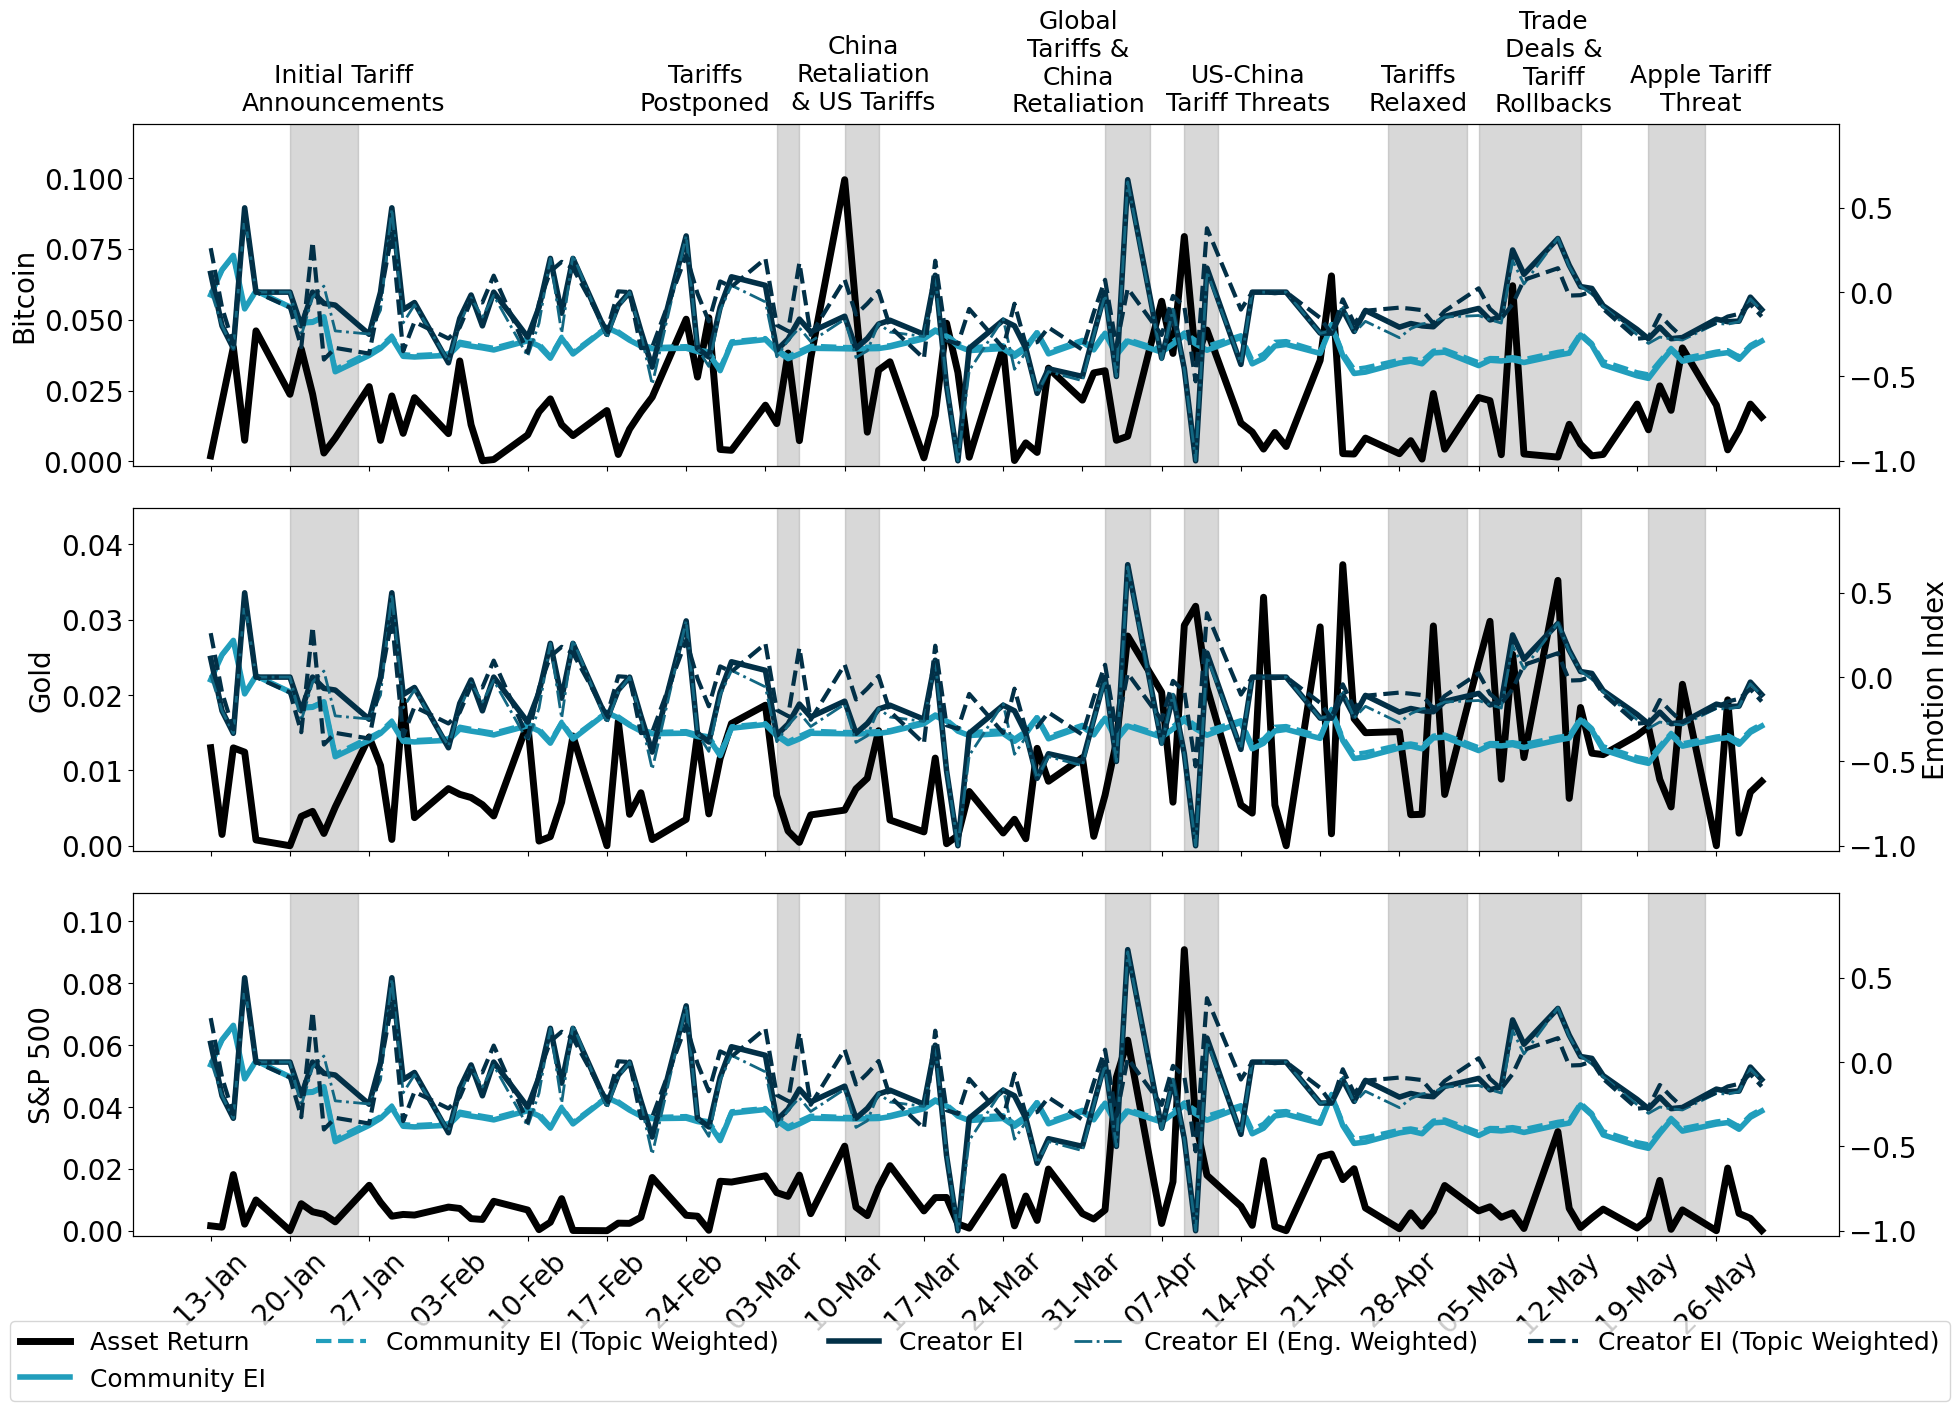

In [6]:
# Test: Time series visualization
print("\n" + "="*70)
print("TEST 2: Time Series Visualization")
print("="*70)
plot_indices_with_returns(df, index_type='ei', include_variants=ei_variants, add_events=True)


TEST 3: Rolling Correlations with Assets


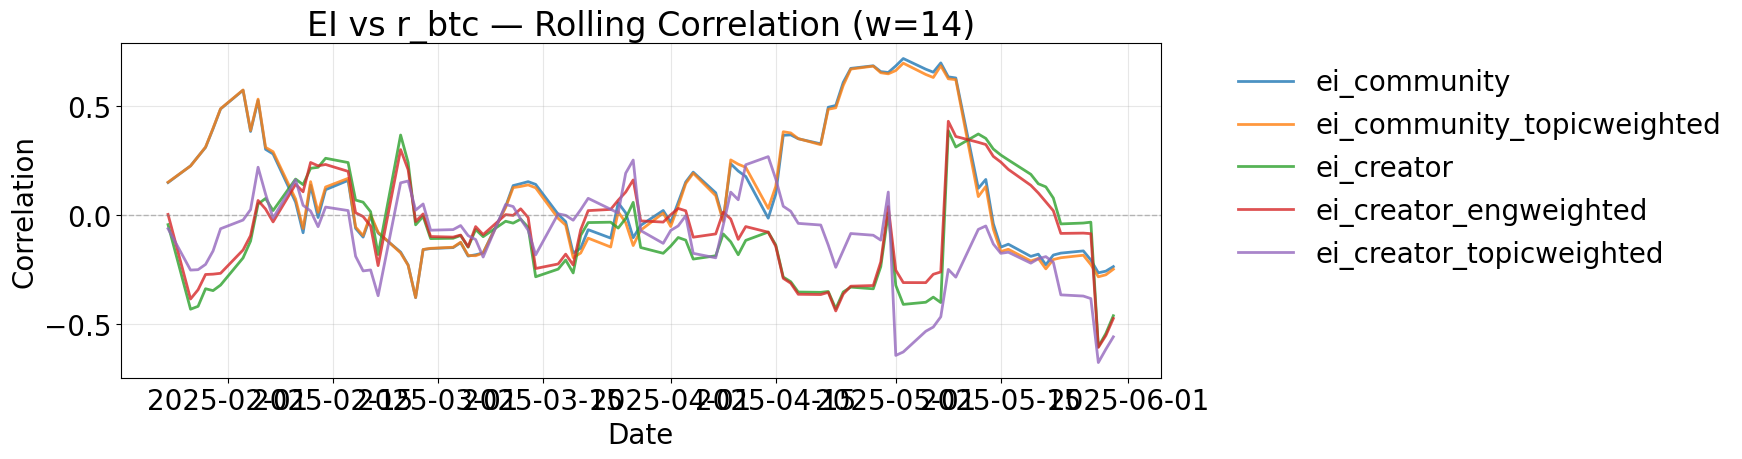

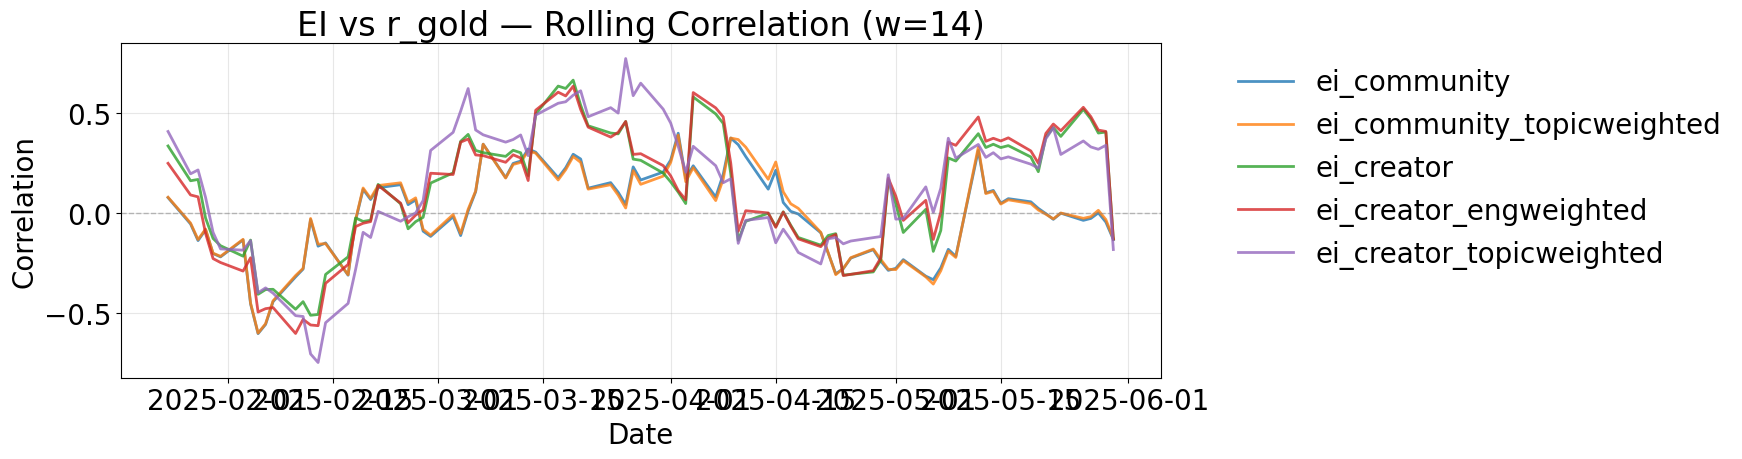

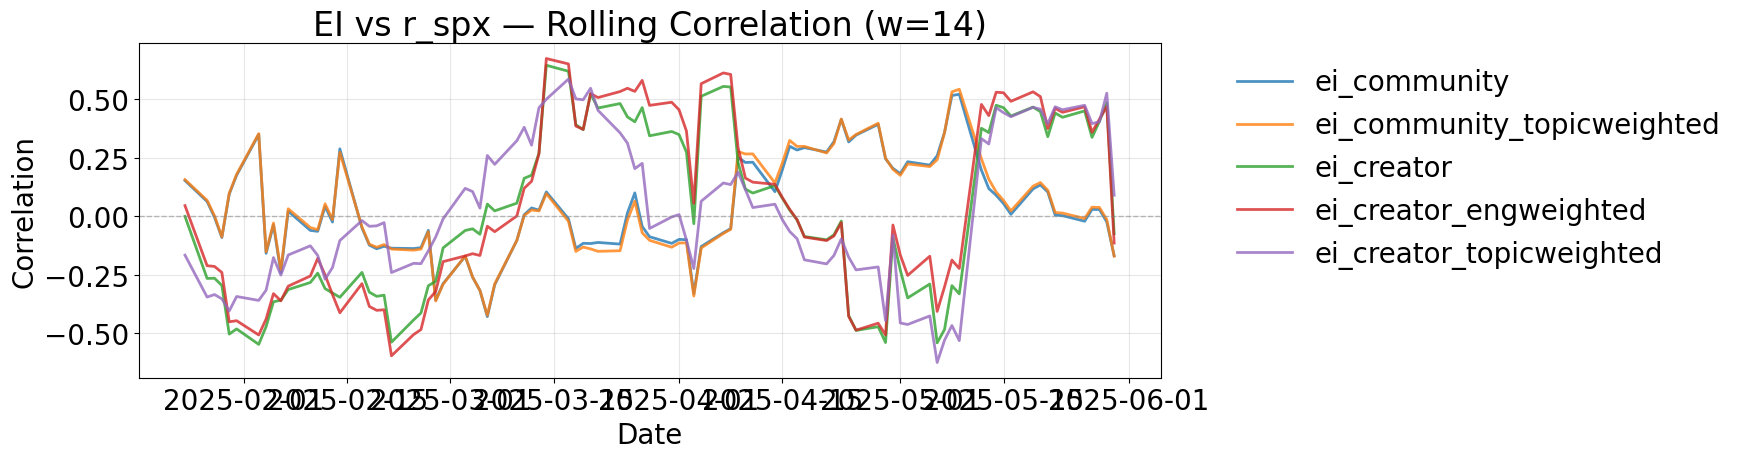

In [7]:
# Test: Rolling correlations with assets
print("\n" + "="*70)
print("TEST 3: Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, ei_variants, ASSET_COLS, 'EI', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if Intensity/Split variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: EI Variants
Running 15 Granger causality tests...
  Index → Asset causality
  Max lag: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  Significant relationships (corrected α=0.05): 0 of 15
  Uncorrected significant (α=0.05): 0

P-values (at optimal lag):


asset,r_btc,r_gold,r_spx
index,,,
ei_community,0.420637,0.166222,0.719601
ei_community_topicweighted,0.429414,0.190624,0.724819
ei_creator,0.511624,0.906327,0.216030
ei_creator_engweighted,0.453085,0.699245,0.248736
ei_creator_topicweighted,0.874366,0.873804,0.750335



Corrected p-values (fdr_bh):


asset,r_btc,r_gold,r_spx
index,,,
ei_community,0.906327,0.906327,0.906327
ei_community_topicweighted,0.906327,0.906327,0.906327
ei_creator,0.906327,0.906327,0.906327
ei_creator_engweighted,0.906327,0.906327,0.906327
ei_creator_topicweighted,0.906327,0.906327,0.906327



Significant relationships (α=0.05, corrected):


asset,r_btc,r_gold,r_spx
index,,,
ei_community,0,0,0
ei_community_topicweighted,0,0,0
ei_creator,0,0,0
ei_creator_engweighted,0,0,0
ei_creator_topicweighted,0,0,0


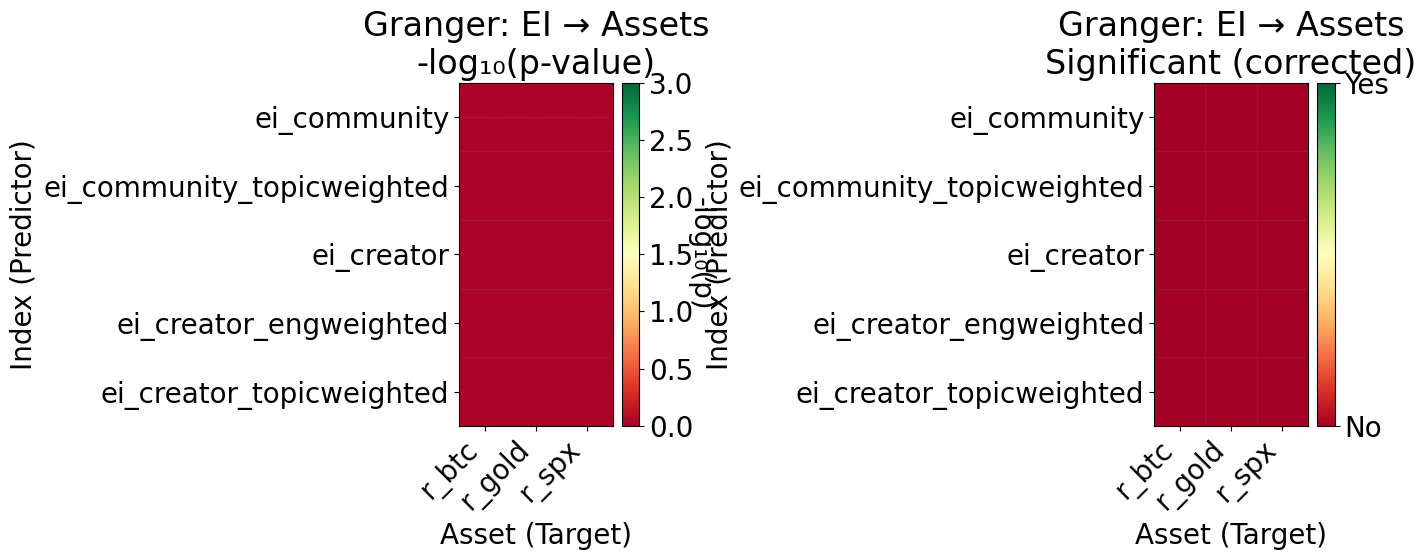

In [10]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

pval_mat, pval_corrected, sig_mat = granger_comparison_variants(
    df, ei_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [11]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(pval_mat, sig_mat, ei_variants)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant,mean_pvalue,min_pvalue
0,ei_community,0,0.435487,0.166222
1,ei_community_topicweighted,0,0.448285,0.190624
2,ei_creator,0,0.544660,0.216030
3,ei_creator_engweighted,0,0.467022,0.248736
4,ei_creator_topicweighted,0,0.832835,0.750335


In [ ]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "ei_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "ei_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "ei_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "ei_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [ ]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in ei_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,intensity,-7.457617,5.459508e-11,✓,0.591343,0.023423,✗
1,intensity_engweighted,-6.418895,1.812158e-08,✓,0.511551,0.039065,✗
2,intensity_topicweighted,-7.397326,7.716633e-11,✓,0.100141,0.100000,✓
3,intensity_engweighted_topicweighted,-8.188227,7.794329e-13,✓,0.426087,0.065911,✓
4,split,-5.715304,7.143778e-07,✓,0.894569,0.010000,✗



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [ ]:
print("\n" + "="*70)
print("Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC)
    display(result)


Bidirectional Granger Tests

Best variant: intensity


intensity ↔ r_btc:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,intensity → r_btc,1,0.311221,0.221596,False,False
1,r_btc → intensity,1,0.229522,0.073297,False,False



intensity ↔ r_gold:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,intensity → r_gold,1,0.337814,0.073406,False,False
1,r_gold → intensity,1,0.788989,0.788989,False,False



intensity ↔ r_spx:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,intensity → r_spx,1,0.566667,0.305558,False,False
1,r_spx → intensity,1,0.001733,0.001733,True,True


## Event Window Analysis

How do Intensity/Split indices behave during major tariff events?

In [ ]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, ei_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "ei_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,intensity_mean,intensity_std,intensity_engweighted_mean,intensity_engweighted_std,intensity_topicweighted_mean,intensity_topicweighted_std,intensity_engweighted_topicweighted_mean,intensity_engweighted_topicweighted_std,split_mean,split_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.020640,NaN,0.015560,NaN,0.086871,NaN,0.029067,NaN,-0.048449,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.124809,NaN,0.122658,NaN,0.045275,NaN,-0.019022,NaN,-0.060122,NaN
8,Tariffs Postponed,Δ during-pre,NaN,0.044534,NaN,0.056915,NaN,0.059717,NaN,0.052477,NaN,-0.008011,NaN
9,Tariffs Postponed,Δ post-during,NaN,-0.029891,NaN,-0.026455,NaN,-0.062844,NaN,-0.046600,NaN,0.024562,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,0.007254,NaN,0.007637,NaN,-0.073665,NaN,-0.070036,NaN,0.007435,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,0.063106,NaN,0.051846,NaN,0.076009,NaN,0.102385,NaN,0.031570,NaN
18,Global Tariffs,Δ during-pre,NaN,-0.026094,NaN,-0.032350,NaN,-0.065430,NaN,-0.058813,NaN,0.007452,NaN
19,Global Tariffs,Δ post-during,NaN,0.021418,NaN,0.018728,NaN,0.060174,NaN,0.057744,NaN,-0.005632,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,0.093520,NaN,0.090101,NaN,0.086305,NaN,0.096273,NaN,0.007996,NaN
24,US-China Tariff Threats,Δ post-during,NaN,-0.203108,NaN,-0.200987,NaN,-0.239634,NaN,-0.154416,NaN,-0.028141,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of Intensity and Split indices

In [ ]:
print("\n" + "="*70)
print("EMOTION INDEX (EI) COMPARISON - SUMMARY")
print("="*70)

print("\n1. INDICES TESTED:")
for i, var in enumerate(ei_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in ei_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: {int(row['n_significant'])} significant")

print("\n4. BEST PERFORMING INDEX:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships: {int(performance.iloc[0]['n_significant'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value: {performance.iloc[0]['mean_pvalue']:.4f}")

print("\n5. KEY INSIGHTS:")
print(f"   - EI captures emotional sentiment in YouTube finance content")
print(f"   - Community indices aggregate emotions across all commenters")
print(f"   - Creator indices weight emotions by channel influence/engagement")
print(f"   - Topic weighting adjusts for relevance to financial themes")
print(f"   - Positive EI may signal optimism; negative EI may predict risk aversion")

print("\n" + "="*70)
print("✓ EMOTION INDEX (EI) ANALYSIS COMPLETE")
print("="*70)


INTENSITY & SPLIT COMPARISON - SUMMARY

1. INDICES TESTED:
   1. intensity
   2. intensity_engweighted
   3. intensity_topicweighted
   4. intensity_engweighted_topicweighted
   5. split

2. CORRELATION WITH ASSETS (mean absolute):
   intensity                               : 0.2226
   intensity_engweighted                   : 0.1860
   intensity_topicweighted                 : 0.0675
   intensity_engweighted_topicweighted     : 0.0773
   split                                   : 0.1527

3. GRANGER CAUSALITY (significant relationships after FDR):
   intensity                               : 0 significant
   intensity_engweighted                   : 0 significant
   intensity_topicweighted                 : 0 significant
   intensity_engweighted_topicweighted     : 0 significant
   split                                   : 0 significant

4. BEST PERFORMING INDEX:
   intensity
   - Significant Granger relationships: 0/3
   - Mean p-value: 0.4052

5. KEY INSIGHTS:
   - Intensity measures